# Modelos Avanzados en Series Temporales

## Nociones Generales del Módulo

Este colab proporciona una descripción general de los modelos avanzados utilizados en el análisis y pronóstico de series temporales, incluyendo la incorporación de variables exógenas, modelos ARIMAX, modelos GARCH, modelos LGBM Regressor, y modelos de descomposición.

## 1. Introducción

Las series temporales son secuencias de datos ordenados en el tiempo.  El análisis de series temporales busca identificar patrones, tendencias y ciclos para realizar predicciones futuras. Los modelos avanzados ofrecen una mayor flexibilidad y precisión en comparación con los modelos tradicionales.
(siempre esta bueno recordar su definición y propósito)

## 2. Modelos de Regresión en Series Temporales

Los modelos de regresión se pueden utilizar para modelar la relación entre una variable dependiente (la serie temporal) y una o más variables independientes (predictores).  A diferencia de la regresión lineal estándar, en las series temporales es crucial considerar la autocorrelación, donde los valores pasados de la serie influyen en los valores futuros.

* **Ejemplo:** Predicción de ventas mensuales basándose en el mes del año, la publicidad, y las ventas de los meses anteriores.

## 3. Incorporación de Variables Exógenas

Las variables exógenas son variables externas que pueden afectar a la serie temporal. Incluir estas variables en el modelo puede mejorar su precisión.

* **Ejemplo:**  Predecir el consumo de energía considerando la temperatura ambiente como variable exógena.

## 4. Modelos ARIMAX

Los modelos ARIMAX (AutoRegressive Integrated Moving Average with eXogenous inputs) extienden los modelos ARIMA incorporando variables exógenas.  Combinan las capacidades de los modelos ARIMA para capturar la autocorrelación con la capacidad de incorporar información externa.

* **Componentes:**
    * **AR (Autoregresivo):**  Dependencia de los valores pasados de la serie.
    * **I (Integración):**  Diferenciación para lograr la estacionariedad.
    * **MA (Media Móvil):**  Dependencia de los errores pasados.
    * **X (Exógenas):**  Variables externas que influyen en la serie.

## 5. Modelos GARCH

Los modelos GARCH (Generalized Autoregressive Conditional Heteroskedasticity) se utilizan para modelar la volatilidad de una serie temporal. La heterocedasticidad es la varianza no constante de los errores a través del tiempo.  Los modelos GARCH asumen que la varianza de los errores (volatilidad) depende de los errores pasados.

* **Heterocedasticidad Condicional:** La varianza de los errores se estima condicionalmente a la información pasada.  Es decir, la volatilidad es variable a lo largo del tiempo.

* **Aplicaciones:**  Finanzas (predicción de volatilidad de activos), análisis de riesgo.

## 6. LGBM Regressor

LightGBM (Light Gradient Boosting Machine) es un algoritmo de boosting que se puede utilizar para realizar regresiones en series temporales.  Es eficiente y escalable, lo que lo hace adecuado para conjuntos de datos grandes.

* **Ventajas:**  Rendimiento rápido, manejo de grandes conjuntos de datos, capacidad de manejar variables categóricas.


## 7. Modelos de Descomposición

Los modelos de descomposición separan una serie temporal en componentes: tendencia, estacionalidad y residuos.

* **Tendencia:**  Componente a largo plazo que representa la dirección general de la serie.
* **Estacionalidad:**  Patrones repetitivos que ocurren a intervalos regulares (semanales, mensuales, anuales).
* **Residuos:**  La parte aleatoria de la serie que no se puede explicar por la tendencia y la estacionalidad.

Una vez descompuesta la serie, cada componente se puede modelar individualmente para obtener un pronóstico más preciso.

## 8. Pronóstico

El objetivo final del análisis de series temporales es realizar pronósticos.  Los modelos descritos anteriormente permiten generar predicciones futuras de la serie temporal.  La evaluación del desempeño del modelo es crucial para determinar su precisión.

* **Métricas de Evaluación:** RMSE, MAE, MAPE


## 9. Recordatorio

Los modelos avanzados ofrecen herramientas poderosas para analizar y pronosticar series temporales.  La elección del modelo adecuado depende de las características específicas de los datos y los objetivos del análisis.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Variables Exogenas

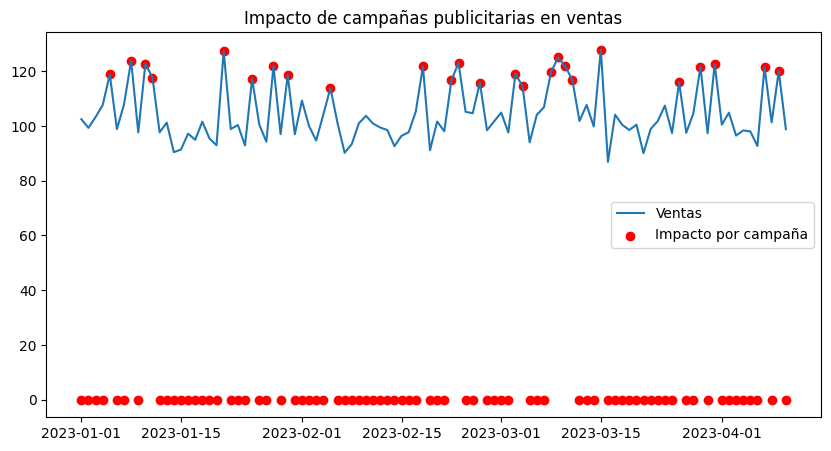

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Crear datos sintéticos
np.random.seed(42)
time = pd.date_range(start="2023-01-01", periods=100, freq="D")
sales = 100 + np.random.normal(0, 5, 100)  # Ventas base
campaign = np.random.choice([0, 1], size=100, p=[0.7, 0.3])  # Campañas (0: no hay, 1: sí hay)
sales += campaign * 20  # Aumentar ventas cuando hay campaña

# Crear DataFrame
data = pd.DataFrame({"Fecha": time, "Ventas": sales, "Campaña": campaign})
data.set_index("Fecha", inplace=True)

# Visualizar
plt.figure(figsize=(10, 5))
plt.plot(data.index, data["Ventas"], label="Ventas")
plt.scatter(data.index, data["Ventas"] * data["Campaña"], color="red", label="Impacto por campaña")
plt.legend()
plt.title("Impacto de campañas publicitarias en ventas")
plt.show()

## Modelo ARIMAX

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


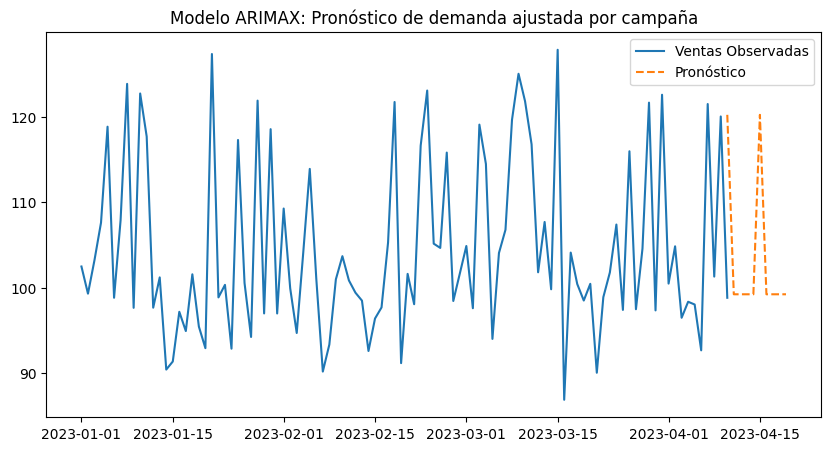

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Ajustar modelo ARIMAX
model = SARIMAX(data["Ventas"], exog=data["Campaña"], order=(1, 1, 1)).fit()

# Pronóstico (10 días con campaña aleatoria)
future_campaign = np.random.choice([0, 1], size=10, p=[0.7, 0.3])
forecast = model.forecast(steps=10, exog=future_campaign)

# Visualizar
plt.figure(figsize=(10, 5))
plt.plot(data.index, data["Ventas"], label="Ventas Observadas")
plt.plot(pd.date_range(data.index[-1], periods=10, freq="D"), forecast, label="Pronóstico", linestyle="--")
plt.title("Modelo ARIMAX: Pronóstico de demanda ajustada por campaña")
plt.legend()
plt.show()

## Modelo GARCH

[*********************100%***********************]  1 of 1 completed


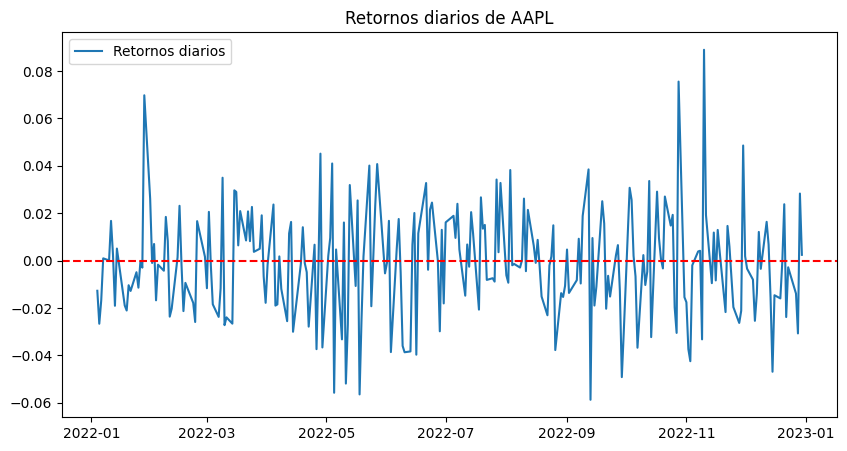

In [ ]:
import yfinance as yf

# Descargar datos financieros
data = yf.download("AAPL", start="2022-01-01", end="2023-01-01")
data["Returns"] = data["Close"].pct_change().dropna()

# Visualizar retornos
plt.figure(figsize=(10, 5))
plt.plot(data.index, data["Returns"], label="Retornos diarios")
plt.axhline(0, color="red", linestyle="--")
plt.title("Retornos diarios de AAPL")
plt.legend()
plt.show()

In [ ]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.3/985.3 kB 14.5 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0005029. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


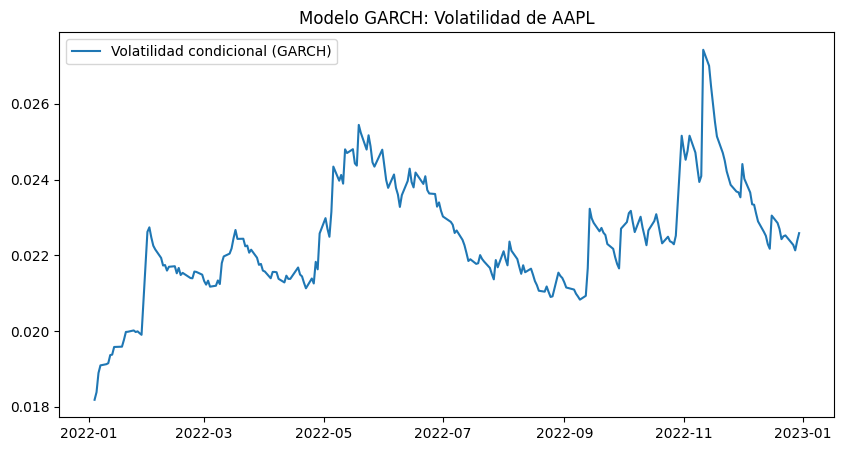

In [ ]:
from arch import arch_model

# Ajustar modelo GARCH
garch_model = arch_model(data["Returns"].dropna(), vol="Garch", p=1, q=1)
garch_fit = garch_model.fit(disp="off")

# Predecir volatilidad
volatility = garch_fit.conditional_volatility

# Visualizar volatilidad
plt.figure(figsize=(10, 5))
plt.plot(data.index[1:], volatility, label="Volatilidad condicional (GARCH)")
plt.title("Modelo GARCH: Volatilidad de AAPL")
plt.legend()
plt.show()

## Modelo LGBM Regressor

In [ ]:
!pip install lightgbm

[*********************100%***********************]  1 of 1 completed


RMSE: 3.7828832882253405
                  Real  Predicción
Date                              
2022-05-25  141.851089  138.510113
2022-05-26  147.632462  139.678279
2022-05-27  146.843185  145.519259
2022-05-31  146.714951  143.632543
2022-06-01  149.181412  147.586967
2022-06-02  143.429642  148.425306
2022-06-03  144.179413  140.750249
2022-06-06  146.714951  144.722332
2022-06-07  145.974991  146.393488
2022-06-08  140.726379  146.432885


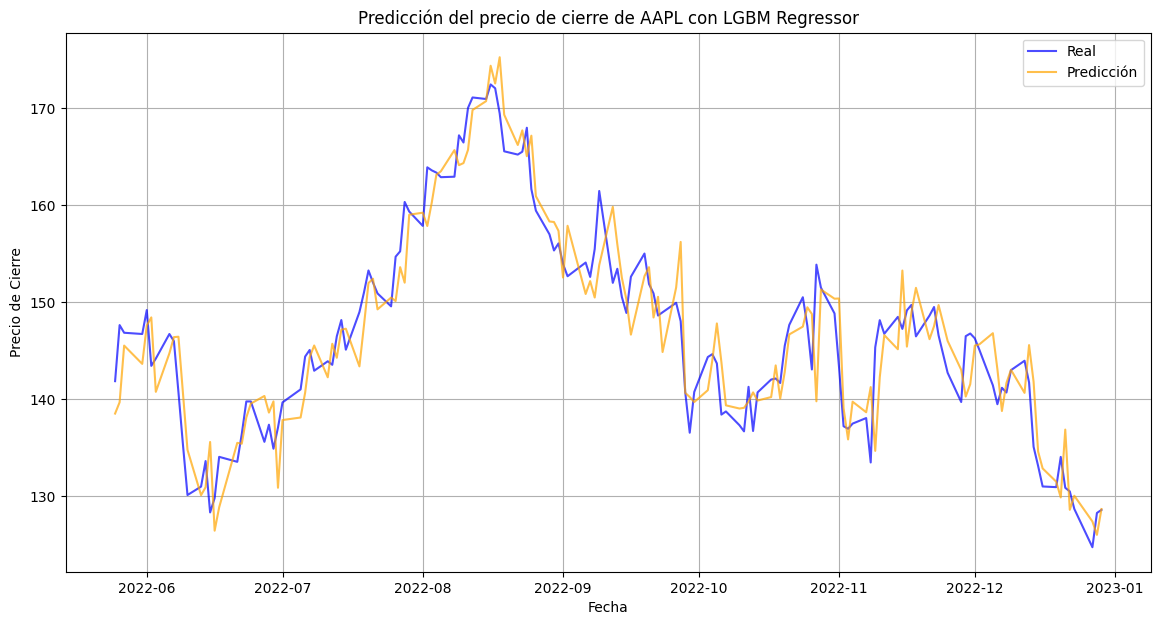

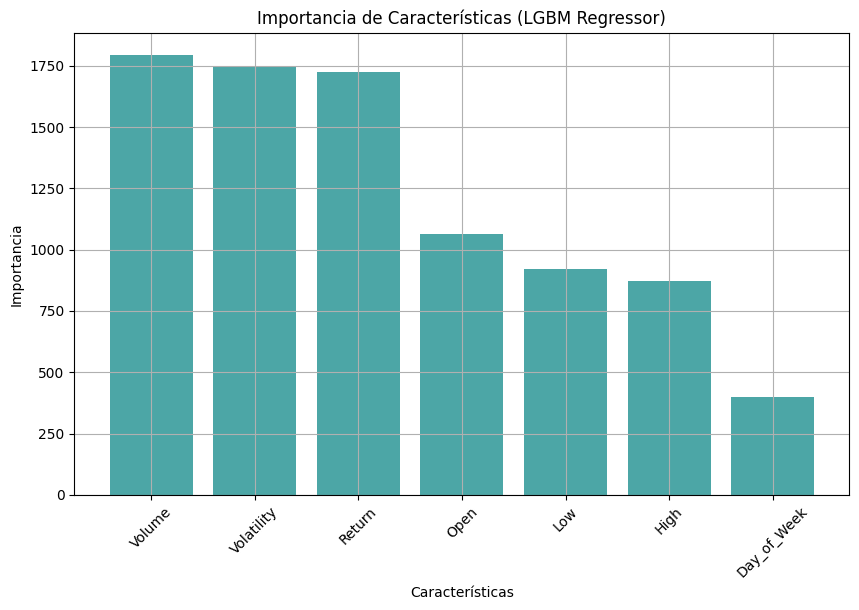

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

from warnings import simplefilter
simplefilter(action='ignore', category=FutureWarning)

# Descargar datos de Yahoo Finance (ejemplo con AAPL)
data = yf.download("AAPL", start="2020-01-01", end="2023-01-01")

# Crear características adicionales
data['Close_Tomorrow'] = data['Close'].shift(-1)  # Variable objetivo (precio de cierre del día siguiente)
data['Day_of_Week'] = data.index.dayofweek  # Día de la semana
data['Return'] = data['Close'].pct_change()  # Retorno porcentual
data['Volatility'] = (data['High'] - data['Low']) / data['Close']  # Volatilidad diaria

# Eliminar valores nulos
data.dropna(inplace=True)

# Seleccionar características (puedes añadir más si es útil para el modelo)
features = ['Open', 'High', 'Low', 'Volume', 'Day_of_Week', 'Return', 'Volatility']
target = 'Close_Tomorrow'

X = data[features]
y = data[target]

# Asegurarse de que X tenga un índice de columnas plano
X.columns = X.columns.get_level_values(0).str.replace('[^a-zA-Z0-9_]', '', regex=True)

# Dividir en conjuntos de entrenamiento y prueba (sin mezclar, dado que es una serie temporal)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Entrenar el modelo LGBM Regressor
model = lgb.LGBMRegressor(
    n_estimators=500,   # Número de árboles
    learning_rate=0.05, # Tasa de aprendizaje
    max_depth=10,       # Profundidad máxima del árbol
    random_state=42,    # Semilla para reproducibilidad
    min_gain_to_split=0.01,  # Ajuste para evitar divisiones con baja ganancia
    force_col_wise=True,
    verbose=-1 # Silenciar los warinings
)
model.fit(X_train, y_train)

# Hacer predicciones
y_pred = model.predict(X_test)

# Evaluar el modelo (usando RMSE como ejemplo)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse}")

# Mostrar algunas predicciones vs valores reales
predicciones_df = pd.DataFrame({'Real': y_test.values, 'Predicción': y_pred}, index=y_test.index)
print(predicciones_df.head(10))

# Visualizar las predicciones vs los valores reales
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test.values, label='Real', color='blue', alpha=0.7)
plt.plot(y_test.index, y_pred, label='Predicción', color='orange', alpha=0.7)
plt.legend()
plt.title('Predicción del precio de cierre de AAPL con LGBM Regressor')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre')
plt.grid()
plt.show()

# Importancia de características
importances = pd.DataFrame({
    'Características': X_train.columns,
    'Importancia': model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(importances['Características'], importances['Importancia'], color='teal', alpha=0.7)
plt.title('Importancia de Características (LGBM Regressor)')
plt.xlabel('Características')
plt.ylabel('Importancia')
plt.xticks(rotation=45)
plt.grid()
plt.show()

## Modelo de Descomposición

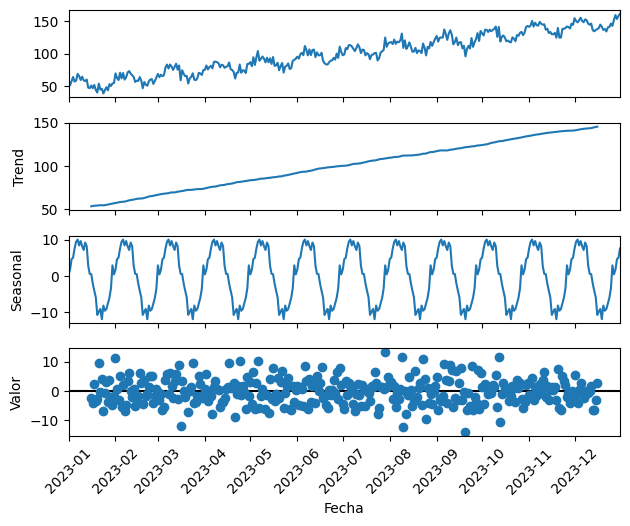

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Crear una serie con estacionalidad
np.random.seed(42)
time = pd.date_range(start="2023-01-01", periods=365, freq="D")
trend = np.linspace(50, 150, 365)  # Tendencia
seasonal = 10 * np.sin(2 * np.pi * np.arange(365) / 30)  # Estacionalidad
noise = np.random.normal(0, 5, 365)  # Ruido
data = trend + seasonal + noise

series = pd.Series(data, index=time)

# Descomposición
decompose = seasonal_decompose(series, model="additive", period=30)
decompose.plot()
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.xticks(rotation=45)
plt.show()

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp7jcxziwa/04b0ad9x.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp7jcxziwa/4575qc7r.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=5932', 'data', 'file=/tmp/tmp7jcxziwa/04b0ad9x.json', 'init=/tmp/tmp7jcxziwa/4575qc7r.json', 'output', 'file=/tmp/tmp7jcxziwa/prophet_model1un_xiq1/prophet_model-20250204182302.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:23:02 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:23:02 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


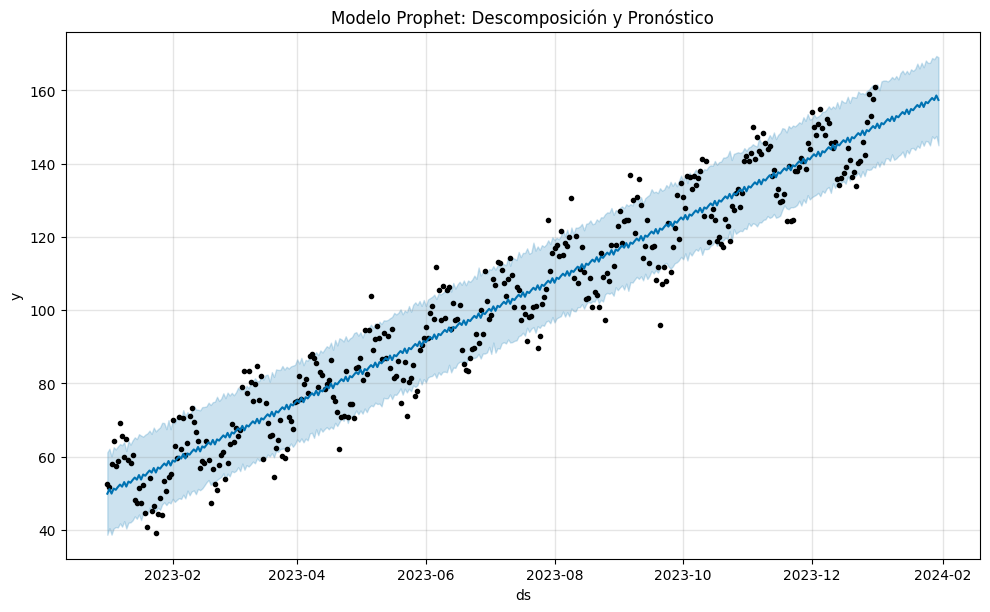

In [ ]:
from prophet import Prophet

# Preparar datos para Prophet
df = series.reset_index()
df.columns = ["ds", "y"]

# Ajustar modelo Prophet
model = Prophet()
model.fit(df)

# Crear pronóstico
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# Visualizar
fig = model.plot(forecast)
plt.title("Modelo Prophet: Descomposición y Pronóstico")
plt.show()